In [43]:
!pip install rioxarray

Defaulting to user installation because normal site-packages is not writeable
     -------------------------------------- 53.7/53.7 kB 689.8 kB/s eta 0:00:00


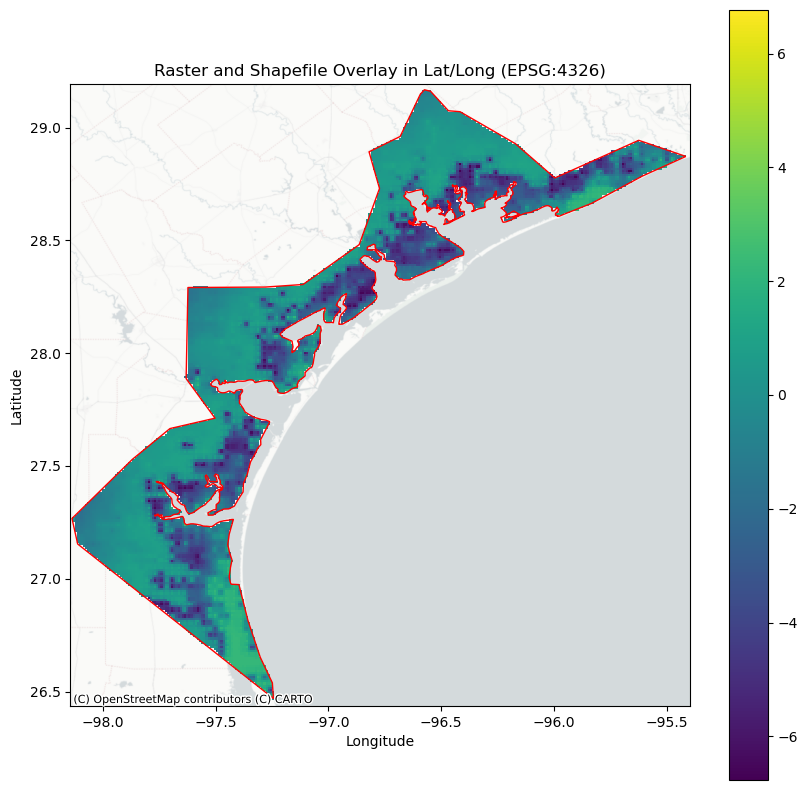

In [44]:
import rasterio
import rioxarray as rxr
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx

# Paths to your files
raster_path = r"D:\Phd Research\GIS\MXD\Flood Map\5yr_return_period.tif"
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Load and reproject the raster to EPSG:4326
raster = rxr.open_rasterio(raster_path, masked=True)
raster = raster.rio.reproject("EPSG:4326")  # Reproject to WGS84 (Lat/Long)

# Load the shapefile and reproject it to EPSG:4326
shapefile = gpd.read_file(shapefile_path).to_crs(epsg=4326)

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the reprojected raster
raster.plot(ax=ax, cmap="viridis", add_colorbar=True)

# Overlay the reprojected shapefile
shapefile.plot(ax=ax, color='none', edgecolor='black', linewidth=1)

# Add a base map for context
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.PositronNoLabels)

# Set title and labels
ax.set_title("Raster and Shapefile Overlay in Lat/Long (EPSG:4326)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Show the plot
plt.show()



Raster shape: (301, 265), CRS: EPSG:32614
Raster contains NaN values, replacing with zero.
Shapefile CRS: EPSG:32614
Reprojected raster to EPSG:4326.


C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\matplotlib\colors.py:1349: RuntimeWarning: overflow encountered in subtract
  resdat -= vmin


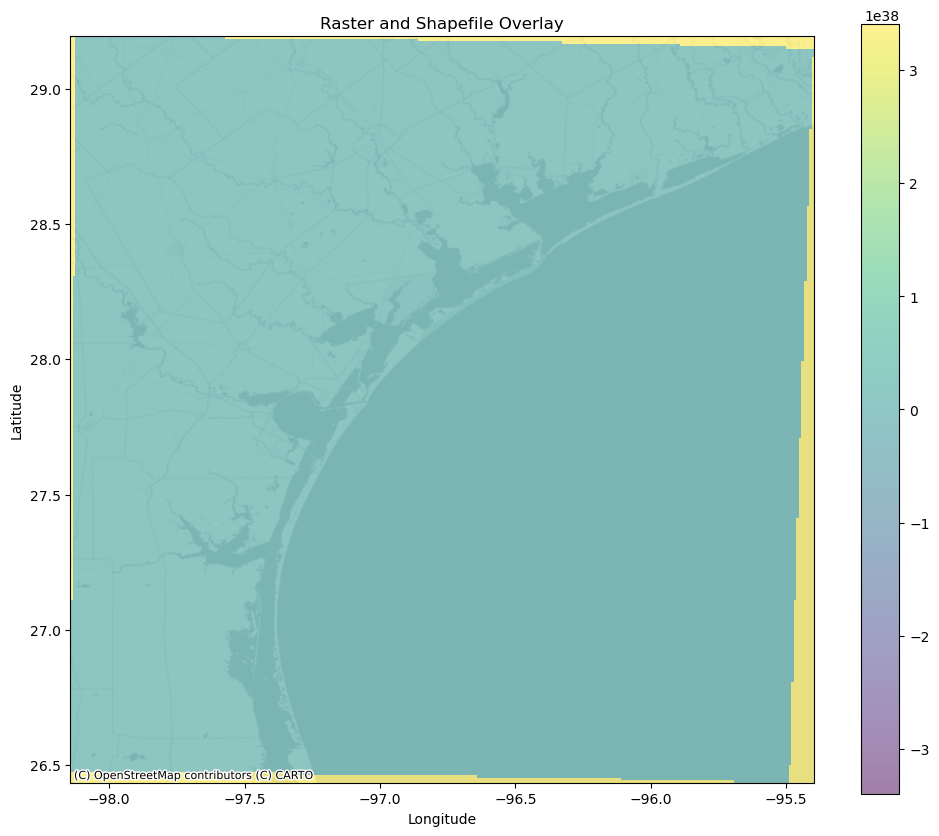

In [51]:
import rasterio
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx

# Paths to your files
raster_path = r"D:\Phd Research\GIS\MXD\Flood Map\5yr_return_period.tif"
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Load the raster file
raster = rxr.open_rasterio(raster_path, masked=True).squeeze()  # Remove singleton dimensions
print(f"Raster shape: {raster.shape}, CRS: {raster.rio.crs}")  # Check raster shape and CRS

# Check for NaN values in the raster
if np.isnan(raster).any():
    print("Raster contains NaN values, replacing with zero.")
    raster = raster.fillna(0)  # Replace NaNs with 0 (or you can use another appropriate method)

# Load the shapefile
shapefile = gpd.read_file(shapefile_path)
print(f"Shapefile CRS: {shapefile.crs}")  # Check shapefile CRS

# Reproject shapefile to match raster CRS
if shapefile.crs != raster.rio.crs:
    shapefile = shapefile.to_crs(raster.rio.crs)
    print("Reprojected shapefile to match raster CRS.")

# Reproject raster to EPSG:4326 (if necessary)
if raster.rio.crs != "EPSG:4326":
    raster = raster.rio.reproject("EPSG:4326")
    print("Reprojected raster to EPSG:4326.")

# Plotting
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the raster
raster.plot(ax=ax, cmap='viridis', alpha=0.5)  # Use alpha for transparency

# Overlay the shapefile
shapefile.plot(ax=ax, color='none', edgecolor='red', linewidth=1)

# Set title and labels
ax.set_title("Raster and Shapefile Overlay")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add a basemap for context
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.PositronNoLabels)

# Show the plot
plt.show()
